In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/Users/rithwiknagavelli/Documents/Weather-ML-Project/weather.csv')
df.head()

,Data.Precipitation,Date.Full,Date.Month,Date.Week of,Date.Year,Station.City,Station.Code,Station.Location,Station.State,Data.Temperature.Avg Temp,Data.Temperature.Max Temp,Data.Temperature.Min Temp,Data.Wind.Direction,Data.Wind.Speed
0,0.00,2016-01-03,1,3,2016,Birmingham,BHM,"Birmingham, AL",Alabama,39,46,32,33,4.33
1,0.00,2016-01-03,1,3,2016,Huntsville,HSV,"Huntsville, AL",Alabama,39,47,31,32,3.86
2,0.16,2016-01-03,1,3,2016,Mobile,MOB,"Mobile, AL",Alabama,46,51,41,35,9.73
3,0.00,2016-01-03,1,3,2016,Montgomery,MGM,"Montgomery, AL",Alabama,45,52,38,32,6.86
4,0.01,2016-01-03,1,3,2016,Anchorage,ANC,"Anchorage, AK",Alaska,34,38,29,19,7.80


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16743 entries, 0 to 16742
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Data.Precipitation         16743 non-null  float64
 1   Date.Full                  16743 non-null  str    
 2   Date.Month                 16743 non-null  int64  
 3   Date.Week of               16743 non-null  int64  
 4   Date.Year                  16743 non-null  int64  
 5   Station.City               16743 non-null  str    
 6   Station.Code               16743 non-null  str    
 7   Station.Location           16743 non-null  str    
 8   Station.State              16743 non-null  str    
 9   Data.Temperature.Avg Temp  16743 non-null  int64  
 10  Data.Temperature.Max Temp  16743 non-null  int64  
 11  Data.Temperature.Min Temp  16743 non-null  int64  
 12  Data.Wind.Direction        16743 non-null  int64  
 13  Data.Wind.Speed            16743 non-null  float64
dtypes

## Problem Framing

Goal: I want to be able to predict a station's weekly average temperature from features avaliable at prediction time.

Target: `Data.Wind.Speed Temp`

Leakage exclusions: None


In [5]:
ny = df[df['Station.State'] == 'New York']
ny["Station.City"].value_counts()

Station.City
Albany         53
Binghamton     53
Buffalo        53
Glens Falls    53
Islip          53
New York       53
Rochester      53
Syracuse       53
Name: count, dtype: int64

In [6]:
ny["Data.Wind.Speed"].describe()

count    424.000000
mean       6.929929
std        2.449856
min        1.800000
25%        5.355000
50%        6.510000
75%        8.455000
max       15.710000
Name: Data.Wind.Speed, dtype: float64

In [7]:
cutin_mph = 5 * 2.237
above_cutin = (ny["Data.Wind.Speed"] > cutin_mph).mean()*100
above_cutin

np.float64(5.89622641509434)

In [8]:
rated_mph = 8 * 2.237
above_rated = (ny["Data.Wind.Speed"] > rated_mph).mean()*100
above_rated

np.float64(0.0)

In [9]:
ny.groupby("Date.Month")["Data.Wind.Speed"].mean()

Date.Month
1     8.798333
2     8.767188
3     6.578437
4     7.519687
5     5.870250
6     6.634375
7     6.062500
8     5.660000
9     5.073750
10    6.506000
11    7.104375
12    8.237813
Name: Data.Wind.Speed, dtype: float64

In [10]:
import matplotlib.pyplot as plt

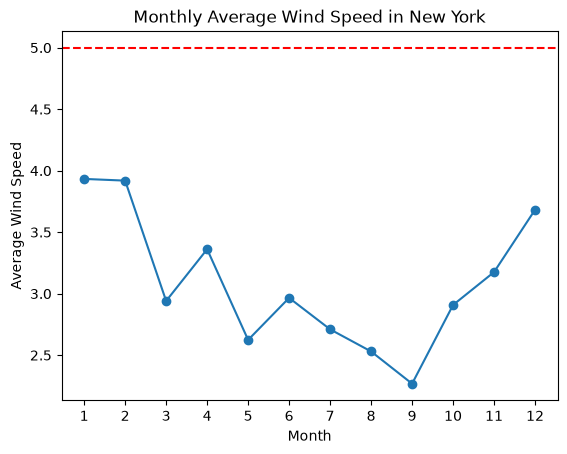

In [ ]:
monthly_ms = ny.groupby("Date.Month")["Data.Wind.Speed"].mean() / 2.237
plt.plot(monthly_ms.index, monthly_ms.values, marker='o', label = 'Avg Wind Speed')
plt.axhline(y=5, color='red', linestyle='--', label='Cut-in Speed (5 m/s)')
plt.xlabel("Month")
plt.ylabel("Average Wind Speed")
plt.title("Average Montly Wind Speed in New York - New York Stations (2016)")
plt.xticks(range(1, 13))
plt.show()

Add the wind rose (direction + speed)

In [17]:
import numpy as np

In [ ]:
#Define the 8 compass sectors which are each 45 degrees wide and they are centered on N/NE/E/SE/S/SW/W/N@
bins = np.arange (-22.5, 360, 45)

labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

#Wrap directions so values near 360 fold back towards 0
direction_wrapped = (ny["Data.Wind.Direction"] * 10) % 360
ny_sector = pd.cut(direction_wrapped, bins=bins, labels=labels, ordered=False)

ny_sector.value_counts()


# Prevailing wind is out of the southwest which matches meteorlogical data out of the Northeast (winds are westerly to southwesterly)
# Predominantly SW tells them which way to orient. 
# That maps straight onto section 2.5 (Detailed Layout)



Data.Wind.Direction
SW    158
S     113
W      87
SE     37
E      21
NE      4
NW      4
N       0
Name: count, dtype: int64

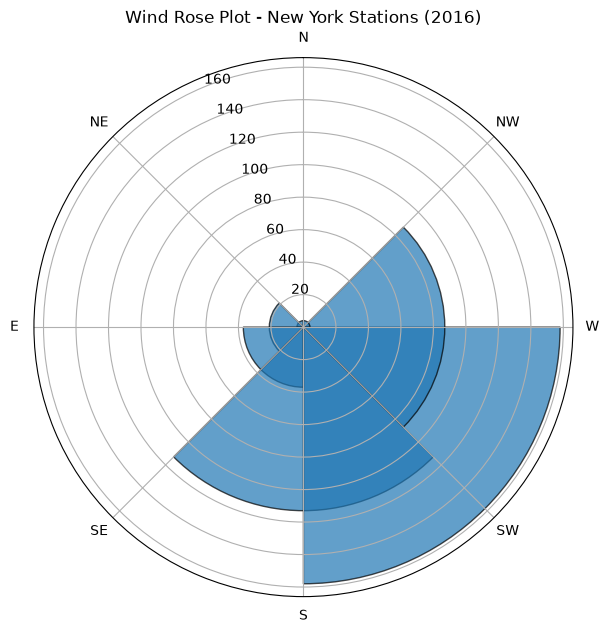

In [25]:
# Wind rose plot

order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
counts = ny_sector.value_counts().reindex(order).fillna(0)

angles = np.linspace(0, 2 * np.pi, 8, endpoint=False)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection = 'polar')
ax.set_theta_zero_location('N') # Puts North at the top 
ax.bar(angles, counts.values, width=2*np.pi/4, edgecolor='black', alpha=0.7)
ax.set_xticks(angles)
ax.set_xticklabels(order)
ax.set_title("Wind Rose Plot - New York Stations (2016)")
plt.show()